In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l
torch.set_printoptions(2)

In [2]:
#@save
def multibox_prior(data, sizes, ratios):
    """生成以每个像素为中心具有不同形状的锚框"""
    in_height, in_width = data.shape[-2:]
    device, num_sizes, num_ratios = data.device, len(sizes), len(ratios)
    boxes_per_pixel = (num_sizes + num_ratios - 1)
    size_tensor = torch.tensor(sizes, device=device)
    ratio_tensor = torch.tensor(ratios, device=device)

    # 为了将锚点移动到像素的中心，需要设置偏移量。
    # 因为一个像素的高为1且宽为1，我们选择偏移我们的中心0.5
    offset_h, offset_w = 0.5, 0.5
    steps_h = 1.0 / in_height  # 在y轴上缩放步长
    steps_w = 1.0 / in_width  # 在x轴上缩放步长

    # 生成锚框的所有中心点
    center_h = (torch.arange(in_height, device=device) + offset_h) * steps_h
    center_w = (torch.arange(in_width, device=device) + offset_w) * steps_w
    shift_y, shift_x = torch.meshgrid(center_h, center_w, indexing='ij')
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)#reshape(-1) 将二维矩阵展平成一维，每个元素对应一个像素中心

    # 生成“boxes_per_pixel”个高和宽，
    # 之后用于创建锚框的四角坐标(xmin,xmax,ymin,ymax)
    w = torch.cat((size_tensor * torch.sqrt(ratio_tensor[0]),# 所有尺度 × sqrt(第一个比率)
                   sizes[0] * torch.sqrt(ratio_tensor[1:]))) * in_height / in_width 
    # 第一个尺度 × sqrt(剩下的比率)额外乘以 in_height / in_width 是为了处理非正方形图片的宽高比补偿。
    h = torch.cat((size_tensor / torch.sqrt(ratio_tensor[0]),# 所有尺度 / sqrt(第一个比率)
                   sizes[0] / torch.sqrt(ratio_tensor[1:])))# 第一个尺度 / sqrt(剩下的比率)
    
    # 除以2来获得半高和半宽
    #torch.stack((-w, -h, w, h)) 形状 (4, boxes_per_pixel)
    #.T 转置为 (boxes_per_pixel, 4)，对应每个锚框的 (xmin, ymin, xmax, ymax) 偏移量
    #.repeat(H*W, 1) 将每个像素中心用的同一组偏移量重复 h*w 次
    #/2：因为是"半宽半高"（从中心到边缘的距离）
    anchor_manipulations = torch.stack((-w, -h, w, h)).T.repeat(
                                        in_height * in_width, 1) / 2

    # 每个中心点都将有“boxes_per_pixel”个锚框，
    # 所以生成含所有锚框中心的网格，重复了“boxes_per_pixel”次
    out_grid = torch.stack([shift_x, shift_y, shift_x, shift_y],
                dim=1).repeat_interleave(boxes_per_pixel, dim=0)#每个中心点的坐标 (cx, cy, cx, cy)，重复 boxes_per_pixel 次
    output = out_grid + anchor_manipulations#中心坐标 + 偏移量 = 最终锚框的四角坐标
    return output.unsqueeze(0)#添加 batch 维度，返回形状 (1, H*W*boxes_per_pixel, 4)

In [3]:
#返回的锚框变量Y的形状
img=d2l.plt.imread('C:/Users/高荣轩/Desktop/dog and cat.jpg')
h,w=img.shape[:2]

print(h,w)
X=torch.rand(size=(1,3,h,w))
Y=multibox_prior(X,sizes=[0.75,0.5,0.25],ratios=[1,2,0.5])
Y.shape

300 450


torch.Size([1, 675000, 4])

In [4]:
#访问以250，250为中心的锚框
boxes=Y.reshape(h,w,5,4)#分别表示高，宽，锚框数（s+r-1），四点坐标
boxes[250,250,0,:]#前两个250表示以250为中心，0表示第一个以此为中心的锚框，：表示四点坐标

tensor([0.31, 0.46, 0.81, 1.21])

In [5]:
def show_bboxes(axes,bboxes,labels=None,colors=None):
    def _make_list(obj,default_values=None):
        if obj is None:
            obj=default_values
        elif not isinstance(obj,(list,tuple)):
            obj=[obj]
        return obj
    
    labels=_make_list(labels)#将标签转为列表，None 则保持 None
    colors=_make_list(colors,['b','g','r','m','c'])#颜色默认使用蓝、绿、红、品红、青

    for i,bbox in enumerate(bboxes):#遍历所有边界框
        color=colors[i%len(colors)]#循环使用颜色列表（取模实现循环）
        rect=d2l.bbox_to_rect(bbox.detach().numpy(),color)#将 PyTorch 张量分离并转为 NumPy 数组,d2l 工具函数，将边界框转为 matplotlib 的 Rectangle 对象
        axes.add_patch(rect)#将矩形添加到坐标轴上
        if labels and len(labels)>i:#如果有标签且当前索引有效
            text_color='k' if color == 'w' else 'w'#智能选择文字颜色：背景白则用黑字，否则用白字
            axes.text(rect.xy[0],rect.xy[1],labels[i],#文字的 x, y 坐标（矩形左上角）和第 i 个边界框的标签
                      va='center',ha='center',fontsize=9,color=text_color,#文字垂直和水平居中,字体大小 9,文字颜色
                      bbox=dict(facecolor=color,lw=0))#文字背景框：填充颜色与边界框相同，无边框线

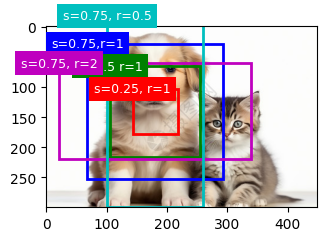

In [6]:
d2l.set_figsize()
bbox_scale=torch.tensor((w,h,w,h))
fig=d2l.plt.imshow(img)
show_bboxes(fig.axes,boxes[140,180,:,:] * bbox_scale,
            ['s=0.75,r=1','s=0.5 r=1', 's=0.25, r=1', 's=0.75, r=2','s=0.75, r=0.5'])

In [7]:
#交并比(IoU)
def box_iou(boxes1,boxes2):
    """boxes1:第一组边界框，形状 (N, 4)，每行 [x1, y1, x2, y2]
       boxes2:第二组边界框，形状 (M, 4)，每行 [x1, y1, x2, y2]
    """
    box_area=lambda boxes:((boxes[:,2]-boxes[:,0])*#宽度 = x2 - x1 * 高度 = y2 - y1
                           (boxes[:,3]-boxes[:,1]))
    areas1=box_area(boxes1)
    areas2=box_area(boxes2)
    inter_upperlefts=torch.max(boxes1[:,None,:2],boxes2[:,:2])#在第1维插入新维度，形状变为 (N, 1, 2)，取每个框的左上角 (x1, y1)
    inter_lowerrights=torch.min(boxes1[:,None,2:],boxes2[:,2:])#形状 (N, 1, 2)，取每个框的右下角 (x2, y2)
    inters=(inter_lowerrights-inter_upperlefts).clamp(min=0)#将负值截断为 0，处理无交集的情况（注意：右下-左上）
    inter_areas=inters[:,:,0]*inters[:,:,1]#交集宽度 Δx，形状 (N, M),交集高度 Δy，形状 (N, M)
    union_areas=areas1[:,None]+areas2-inter_areas#areas1形状 (N, 1)，广播为 (N, M),areas2形状 (M，)，广播为 (N, M)
    return inter_areas/union_areas

In [8]:
#将真实边界框分配给锚框
def assign_anchor_to_bbox(ground_truth,anchors,device,iou_threshold=0.5):
    num_anchors,num_gt_boxes=anchors.shape[0],ground_truth.shape[0]
    jaccard=box_iou(anchors,ground_truth)#形状 (N, M) 的 IoU 矩阵，jaccard[i][j] = 锚框 i 与 GT 框 j 的 IoU
    #torch.full((num_anchors,), -1, ...),创建长度为num_anchors的张量，所有元素初始化为 -1
    anchors_bbox_map=torch.full((num_anchors,),-1,dtype=torch.long,device=device)
    #沿第 1 维（列方向）取最大值,max_ious形状 (N,)，每个锚框与所有 GT 框的最大 IoU,indices形状 (N,)，每个锚框最大 IoU 对应的 GT 框索引
    max_ious,indices=torch.max(jaccard,dim=1)
    #anc_i:满足阈值条件的锚框索引列表,torch.nonzero(...):找出满足条件的锚框索引
    anc_i=torch.nonzero(max_ious>=0.5).reshape(-1)#将满足>=0.5的最大iou索引展平成一维向量列表
    #box_j:与 anc_i 一一对应的 GT 框索引
    box_j=indices[max_ious>=0.5]
    #将满足>=0.5的锚框分配给真实框GT
    anchors_bbox_map[anc_i]=box_j
    #删除被选中的那条GT列
    col_discard=torch.full((num_anchors,),-1)
    #删除被选中的那条锚框行
    row_discard=torch.full((num_gt_boxes,),-1)
    #循环 M 次，确保每个 GT 框至少分配到一个锚框
    for _ in range(num_gt_boxes):
        max_idx=torch.argmax(jaccard)#在整个 IoU 矩阵中找到最大值的扁平化索引（一维位置）
        box_idx=(max_idx % num_gt_boxes).long()#取模 → 得到列索引（GT 框编号）,每经过 M 个元素换一行，余数就是当前行中第几个
        anc_idx=(max_idx / num_gt_boxes).long()#除法 → 得到行索引（锚框编号）,商告诉你跳过了多少完整行
        anchors_bbox_map[anc_idx]=box_idx
        jaccard[:,box_idx]=col_discard#将该 GT 框对应的整列设为 -1，防止它被再次分配
        jaccard[anc_idx,:]=row_discard#将该锚框对应的整行设为 -1，防止它被再次分配
    return anchors_bbox_map

In [9]:
#标记类别和偏移量
def offset_boxes(anchors,assigned_bb,eps=1e-6):
    """对锚框偏移量的转换"""
    c_anc=d2l.box_corner_to_center(anchors)
    c_assigned_bb=d2l.box_corner_to_center(assigned_bb)
    offset_xy=10*(c_assigned_bb[:,:2]-c_anc[:,:2])/c_anc[:,2:]
    offset_wh=5*torch.log(eps+c_assigned_bb[:,2:]/c_anc[:,2:])
    offset=torch.cat([offset_xy,offset_wh],axis=1)
    return offset
def multibox_target(anchors,labels):
    """
    使用真实边界框标记锚框
    如果一个锚框没有被分配真实边界框，我们只需将锚框的类别标记为背景（background）。 
    背景类别的锚框通常被称为负类锚框，其余的被称为正类锚框。 
    我们使用真实边界框（labels参数）实现以下multibox_target函数，
    来标记锚框的类别和偏移量（anchors参数）。 
    此函数将背景类别的索引设置为零，然后将新类别的整数索引递增一。
    """
    batch_size, anchors = labels.shape[0], anchors.squeeze(0)
    batch_offset, batch_mask, batch_class_labels = [], [], []
    device, num_anchors = anchors.device, anchors.shape[0]
    for i in range(batch_size):
        label = labels[i, :, :]
        anchors_bbox_map = assign_anchor_to_bbox(
            label[:, 1:], anchors, device)
        bbox_mask = ((anchors_bbox_map >= 0).float().unsqueeze(-1)).repeat(
            1, 4)
        # 将类标签和分配的边界框坐标初始化为零
        class_labels = torch.zeros(num_anchors, dtype=torch.long,
                                   device=device)
        assigned_bb = torch.zeros((num_anchors, 4), dtype=torch.float32,
                                  device=device)
        # 使用真实边界框来标记锚框的类别。
        # 如果一个锚框没有被分配，标记其为背景（值为零）
        indices_true = torch.nonzero(anchors_bbox_map >= 0)
        bb_idx = anchors_bbox_map[indices_true]
        class_labels[indices_true] = label[bb_idx, 0].long() + 1
        assigned_bb[indices_true] = label[bb_idx, 1:]
        # 偏移量转换
        offset = offset_boxes(anchors, assigned_bb) * bbox_mask
        batch_offset.append(offset.reshape(-1))
        batch_mask.append(bbox_mask.reshape(-1))
        batch_class_labels.append(class_labels)
    bbox_offset = torch.stack(batch_offset)
    bbox_mask = torch.stack(batch_mask)
    class_labels = torch.stack(batch_class_labels)
    return (bbox_offset, bbox_mask, class_labels)
    

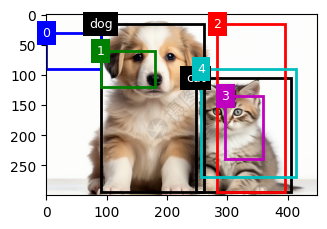

In [10]:
#一个例子
"""
其中第一个元素是类别（0代表狗，1代表猫）,
其余四个元素是左上角和右下角的轴坐标（范围介于0和1之间）,
还构建了五个锚框，用左上角和右下角的坐标进行标记
"""
ground_truth = torch.tensor([[0, 0.2, 0.05, 0.58, 0.98],
                         [1, 0.55, 0.35, 0.9, 0.98]])
anchors = torch.tensor([[0, 0.1, 0.2, 0.3], [0.2, 0.2, 0.4, 0.4],
                    [0.63, 0.05, 0.88, 0.98], [0.66, 0.45, 0.8, 0.8],
                    [0.57, 0.3, 0.92, 0.9]])

fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, ground_truth[:, 1:] * bbox_scale, ['dog', 'cat'], 'k')
show_bboxes(fig.axes, anchors * bbox_scale, ['0', '1', '2', '3', '4']);

In [11]:
labels = multibox_target(anchors.unsqueeze(dim=0),
                         ground_truth.unsqueeze(dim=0))
"""
这个例子中,背景、狗和猫的类索引分别为0、1和2
"""

'\n这个例子中,背景、狗和猫的类索引分别为0、1和2\n'

In [12]:
#锚框和真实边界框的位置返回的类别标签
labels[2]

tensor([[0, 1, 2, 0, 2]])

In [13]:
#展示掩码（mask）变量，形状为（批量大小，锚框数的四倍）， 掩码变量中的元素与每个锚框的4个偏移量一一对应
labels[1]

tensor([[0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1.,
         1., 1.]])

In [14]:
#展示偏移量
labels[0]

tensor([[-0.00e+00, -0.00e+00, -0.00e+00, -0.00e+00,  4.50e+00,  1.07e+01,
          3.21e+00,  7.68e+00, -1.20e+00,  1.61e+00,  1.68e+00, -1.95e+00,
         -0.00e+00, -0.00e+00, -0.00e+00, -0.00e+00, -5.71e-01,  1.08e+00,
          4.17e-06,  2.44e-01]])

In [15]:
#使用非极大值抑制预测边界框
"""
就是用锚框偏移量公式反推处理真实边界框
"""
def offset_inverse(anchors, offset_preds):
    anc = d2l.box_corner_to_center(anchors)
    pred_bbox_xy = (offset_preds[:, :2] * anc[:, 2:] / 10) + anc[:, :2]
    pred_bbox_wh = torch.exp(offset_preds[:, 2:] / 5) * anc[:, 2:]  # 乘，不是加！
    pred_bbox = torch.cat((pred_bbox_xy, pred_bbox_wh), axis=1)
    return d2l.box_center_to_corner(pred_bbox)  # [cx,cy,w,h] -> [x1,y1,x2,y2]

In [16]:
#以nms函数按降序对置信度进行排序并返回其索引
#@save
def nms(boxes, scores, iou_threshold):
    """对预测边界框的置信度进行排序"""
    B = torch.argsort(scores, dim=-1, descending=True)
    keep = []  # 保留预测边界框的指标
    while B.numel() > 0:
        i = B[0]
        keep.append(i)
        if B.numel() == 1: break
        iou = box_iou(boxes[i, :].reshape(-1, 4),
                      boxes[B[1:], :].reshape(-1, 4)).reshape(-1)
        inds = torch.nonzero(iou <= iou_threshold).reshape(-1)
        B = B[inds + 1]
    return torch.tensor(keep, device=boxes.device)

In [17]:
#使用非极大值抑制（NMS）合并属于同一目标的类似的预测边界框
#@save
def multibox_detection(cls_probs, offset_preds, anchors, nms_threshold=0.5,
                       pos_threshold=0.009999999):
    """使用非极大值抑制来预测边界框"""
    device, batch_size = cls_probs.device, cls_probs.shape[0]
    anchors = anchors.squeeze(0)
    num_classes, num_anchors = cls_probs.shape[1], cls_probs.shape[2]
    out = []
    for i in range(batch_size):
        cls_prob, offset_pred = cls_probs[i], offset_preds[i].reshape(-1, 4)
        conf, class_id = torch.max(cls_prob[1:], 0)
        predicted_bb = offset_inverse(anchors, offset_pred)
        keep = nms(predicted_bb, conf, nms_threshold)

        # 找到所有的non_keep索引，并将类设置为背景
        all_idx = torch.arange(num_anchors, dtype=torch.long, device=device)
        combined = torch.cat((keep, all_idx))
        uniques, counts = combined.unique(return_counts=True)
        non_keep = uniques[counts == 1]
        all_id_sorted = torch.cat((keep, non_keep))
        class_id[non_keep] = -1
        class_id = class_id[all_id_sorted]
        conf, predicted_bb = conf[all_id_sorted], predicted_bb[all_id_sorted]
        # pos_threshold是一个用于非背景预测的阈值
        below_min_idx = (conf < pos_threshold)
        class_id[below_min_idx] = -1
        conf[below_min_idx] = 1 - conf[below_min_idx]
        pred_info = torch.cat((class_id.unsqueeze(1),
                               conf.unsqueeze(1),
                               predicted_bb), dim=1)
        out.append(pred_info)
    return torch.stack(out)

In [18]:
anchors = torch.tensor([[0.15, 0.08, 0.55, 0.98], [0.08, 0.2, 0.56, 0.95],
                      [0.15, 0.3, 0.62, 0.91], [0.55, 0.3, 0.9, 0.98]])
offset_preds = torch.tensor([0] * anchors.numel())
cls_probs = torch.tensor([[0] * 4,  # 背景的预测概率
                      [0.9, 0.8, 0.7, 0.1],  # 狗的预测概率
                      [0.1, 0.2, 0.3, 0.9]])  # 猫的预测概率

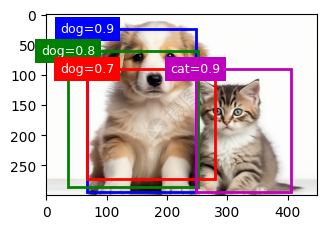

In [19]:
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, anchors * bbox_scale,
            ['dog=0.9', 'dog=0.8', 'dog=0.7', 'cat=0.9'])

In [20]:
output = multibox_detection(cls_probs.unsqueeze(dim=0),
                            offset_preds.unsqueeze(dim=0),
                            anchors.unsqueeze(dim=0),
                            nms_threshold=0.5)
output

tensor([[[ 0.00,  0.90,  0.15,  0.08,  0.55,  0.98],
         [ 1.00,  0.90,  0.55,  0.30,  0.90,  0.98],
         [-1.00,  0.80,  0.08,  0.20,  0.56,  0.95],
         [-1.00,  0.70,  0.15,  0.30,  0.62,  0.91]]])

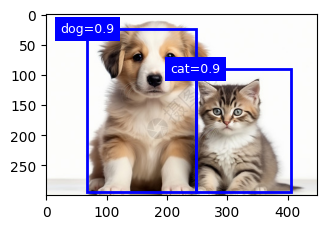

In [21]:
fig = d2l.plt.imshow(img)
for i in output[0].detach().numpy():
    if i[0] == -1:
        continue
    label = ('dog=', 'cat=')[int(i[0])] + str(i[1])
    show_bboxes(fig.axes, [torch.tensor(i[2:]) * bbox_scale], label)